In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping

import optuna
from optuna.trial import Trial

from typing import Tuple, Optional

import time
import os

2026-01-31 23:51:22.918238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769903483.103489      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769903483.157020      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# dataset load

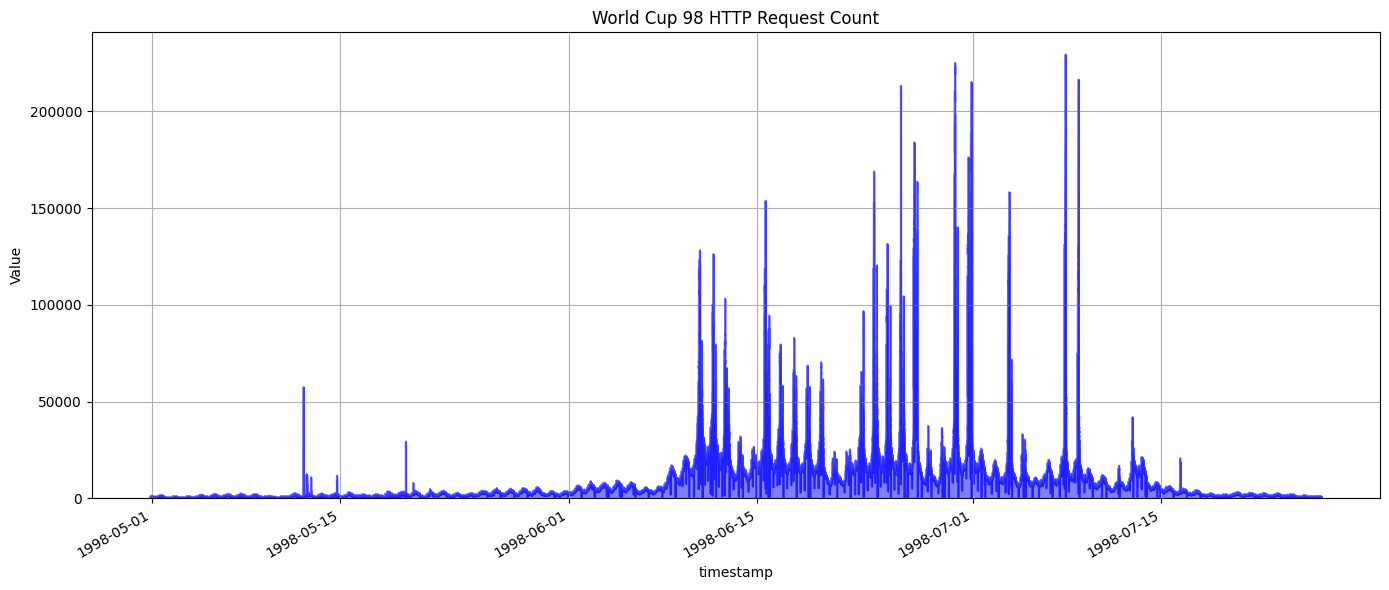

In [2]:
wcdf = pd.read_csv(
        '/kaggle/input/worldcup98/worldcup98.csv',
        usecols=['timestamp', 'value'],
        index_col='timestamp',
        parse_dates=['timestamp']
    ).sort_index()

plt.figure(figsize=(14, 6))

wcdf['value'].plot(kind='area', color='blue', alpha=0.5)

plt.title('World Cup 98 HTTP Request Count')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

# helper

### create sequences aware slit func

In [3]:
def sequences_aware_split(df, train_ratio=0.7, time_step=10):
    "split dataframe into train and test sets while preserving sequence continuity"
    
    total_len = len(df)
    
    available_for_sequences = total_len - time_step
    train_sequences = int(available_for_sequences * train_ratio)
    
    split_point = train_sequences + time_step
    
    train_df = df.iloc[:split_point]
    test_df = df.iloc[split_point:]
    
    return train_df, test_df

### create sequence func

In [4]:
def sequences(dataset: pd.DataFrame, time_step: int = 10):
    x, y = [], []
    
    for i in range(len(dataset) - time_step):
        x.append(dataset[i:i + time_step])
        y.append(dataset[i + time_step])
    
    return [np.array(x), np.array(y)]

### train model class

In [5]:
class BilstmTrainer:
    
    def __init__(self, hidden_units: int = 32, num_layers: int = 1, input_shape: tuple = (10, 1)):
        self.hidden_units = hidden_units
        self.num_layers = num_layers
        self.input_shape = input_shape
        self.model = self._create_model()
        self.history = None
        self.scaler = None
        self.train_data = None
        self.test_data = None
        self.y_test = None
        self.y_pred = None
        self.y_test_value = None
        self.y_pred_value = None

    def _create_model(self):
        model = Sequential()

        for i in range(self.num_layers):
            return_sequences = i < self.num_layers - 1

            if i == 0:
                model.add(Bidirectional(LSTM(
                    units=self.hidden_units, 
                    activation='relu', 
                    return_sequences=return_sequences, 
                    input_shape=self.input_shape
                )))
            else:
                model.add(Bidirectional(LSTM(
                    units=self.hidden_units, 
                    activation='relu', 
                    return_sequences=return_sequences
                )))

        model.add(Dense(1))
        model.compile(optimizer='adam', loss='mse')

        return model

    def fit_model(self, train_data: Optional[Tuple[np.ndarray, np.ndarray]], 
                  epochs: int = 50, batch_size: int = 64, 
                  patience: int = 5, verbose: int = 1):
        self.train_data = train_data
        
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=patience, 
            restore_best_weights=True
        )

        self.history = self.model.fit(
            train_data[0], train_data[1], 
            validation_split=0.2, 
            epochs=epochs, 
            batch_size=batch_size, 
            callbacks=[early_stopping],
            verbose=verbose
        )

    def plot_history(self):
        plt.figure(figsize=(14, 6))

        plt.plot(self.history.history['loss'], label='Training Loss')
        plt.plot(self.history.history['val_loss'], label='Validation Loss')

        plt.title('Model Training History')
        plt.ylabel('Loss (MSE)')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def evaluate_model(self, test_data: Optional[Tuple[np.ndarray, np.ndarray]]):
        self.test_data = test_data
        test_loss = self.model.evaluate(test_data[0], test_data[1])
        return test_loss

    def set_scaler(self, scaler: Optional[TransformerMixin]):
        self.scaler = scaler

    def _predict(self):
        return self.model.predict(self.test_data[0])

    def plot_prediction(self, test_df: pd.DataFrame, time_step: int = 10):
        self.y_test = self.test_data[1]
        self.y_pred = self._predict()
        
        # Transform back to original scale
        self.y_test_value = self.scaler.inverse_transform(self.y_test.reshape(-1, 1))
        self.y_pred_value = self.scaler.inverse_transform(self.y_pred.reshape(-1, 1))
        
        # Align indices with original test data
        test_index = test_df.index[time_step - 1:time_step - 1 + len(self.y_test)]
        
        y_test_value_df = pd.DataFrame(self.y_test_value, index=test_index, columns=['value'])
        y_pred_value_df = pd.DataFrame(self.y_pred_value, index=test_index, columns=['value'])
        
        plt.figure(figsize=(14, 6))
        
        plt.plot(y_test_value_df.index, y_test_value_df['value'], label='Actual')
        plt.plot(y_pred_value_df.index, y_pred_value_df['value'], label='Predicted')
        
        plt.title('HTTP Workload Prediction')
        plt.ylabel('Number of Requests')
        plt.xlabel('Time')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def calculate_metrics(self):
        test_mae = mean_absolute_error(self.y_test_value, self.y_pred_value)
        test_mse = mean_squared_error(self.y_test_value, self.y_pred_value)
        test_rmse = np.sqrt(mean_squared_error(self.y_test_value, self.y_pred_value))
        test_r2 = r2_score(self.y_test_value, self.y_pred_value)

        metrics = {
            "mean_squared_error": test_mse,
            "root_mean_squared_error": test_rmse,
            "mean_absolute_error": test_mae,
            "r_squared": test_r2
        }

        return metrics

    def calculate_prediction_speed(self, warmup_runs: int = 3, n_runs: int = 30):
        x_test = self.test_data[0]
        single_sample = x_test[:1]

        # Warmup runs to stabilize GPU/CPU
        for _ in range(warmup_runs):
            _ = self.model.predict(x_test, verbose=0)

        # Batch prediction timing
        times_batch_pred = []
        
        for run in range(n_runs):
            start_time = time.perf_counter()
            predictions = self.model.predict(x_test, verbose=0)
            end_time = time.perf_counter()
            
            times_batch_pred.append(end_time - start_time)
        
        # Remove outliers (top and bottom 2)
        times_batch_pred = sorted(times_batch_pred)[2:-2]
        
        avg_time_batch = np.mean(times_batch_pred)
        std_time_batch = np.std(times_batch_pred)
        
        # Single prediction timing
        times_single_pred = []

        for run in range(n_runs):
            start_time = time.perf_counter()
            prediction = self.model.predict(single_sample, verbose=0)
            end_time = time.perf_counter()
            
            times_single_pred.append(end_time - start_time)

        # Remove outliers (top and bottom 5)
        times_single_pred = sorted(times_single_pred)[5:-5]
        
        avg_time_single = np.mean(times_single_pred)
        std_time_single = np.std(times_single_pred)
        
        speed_metrics = {
            "avg_batch_time_seconds": avg_time_batch,
            "avg_single_prediction_ms": avg_time_single * 1000,
            "std_batch_time_seconds": std_time_batch,
            "std_single_prediction_ms": std_time_single * 1000,
        }
        
        return speed_metrics

    def save_model(self, model_name: str, path: str = "."):
        tf.saved_model.save(self.model, f'{path}/{model_name}')
        print(f"{model_name} saved successfully")

### hyperparameters optimization func

In [6]:
# custom type aliases 
train_data = Optional[Tuple[np.ndarray, np.ndarray]]
test_data = Optional[Tuple[np.ndarray, np.ndarray]]

def _objective(trial: Trial, 
              train_data: train_data = None, 
              test_data: test_data = None):
    hidden_units = trial.suggest_int('hidden_units', 30, 100, log=True)
    num_layers = trial.suggest_categorical('num_layers', [1, 2])
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256, 512])
    epochs = trial.suggest_categorical('epochs', [50, 100, 150, 250])
    patience = trial.suggest_categorical('patience', [5, 10])

    bilstm_trial = BilstmTrainer(
        hidden_units=hidden_units, 
        num_layers=num_layers, 
        input_shape=(10, 1)
    )
    
    bilstm_trial.fit_model(
        train_data=train_data,
        epochs=epochs, 
        batch_size=batch_size,
        patience=patience,
        verbose=0
    )
    
    test_loss = bilstm_trial.evaluate_model(test_data)

    tf.keras.backend.clear_session()

    return test_loss


def hyperparameter_tuning(train_data: Optional[Tuple[np.ndarray, np.ndarray]] = None, 
                          test_data: Optional[Tuple[np.ndarray, np.ndarray]] = None, 
                          n_trials: int = 50):
    study = optuna.create_study(
        study_name='bilstm hyperparameters optimization',
        direction='minimize', 
        sampler=optuna.samplers.TPESampler(seed=42), 
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
    )

    objective_with_params = lambda trial: _objective(trial, train_data, test_data)
    
    study.optimize(objective_with_params, n_trials=n_trials, show_progress_bar=True)

    return study.best_params

# dataset preprocessing

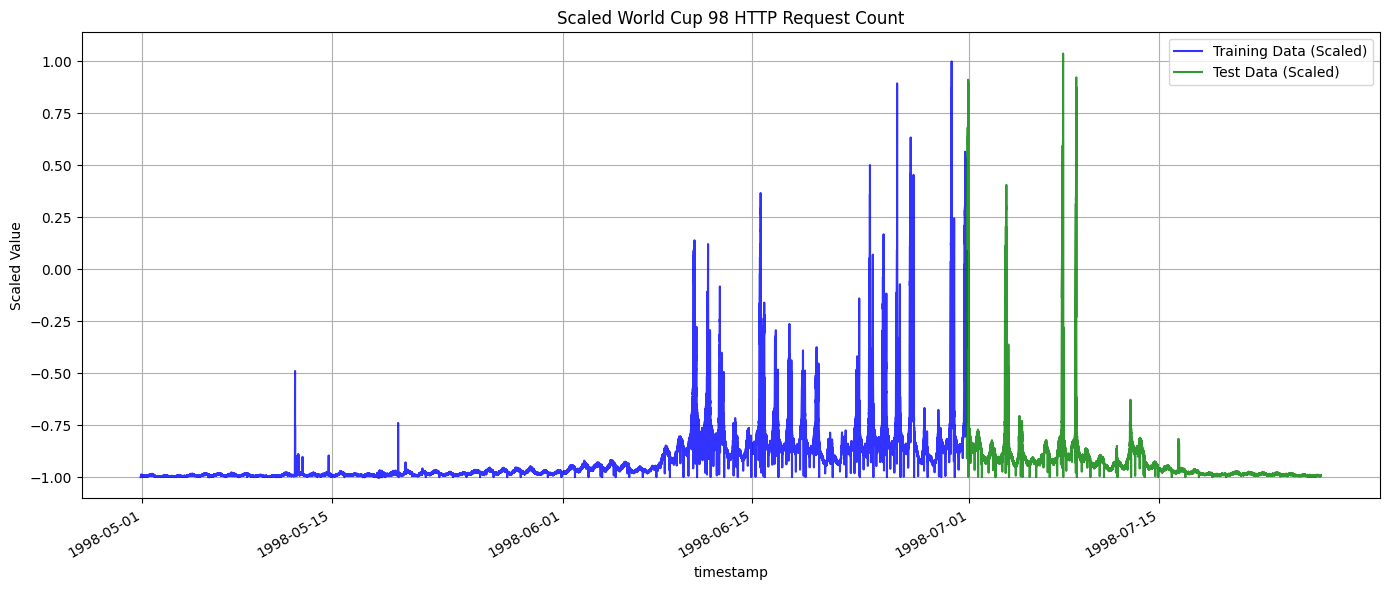

In [7]:
train_df, test_df = sequences_aware_split(wcdf)

scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

train_data = sequences(train_scaled)
test_data = sequences(test_scaled)

train_scaled_df = pd.DataFrame(train_scaled, index=train_df.index, columns=['scaled_value'])
test_scaled_df = pd.DataFrame(test_scaled, index=test_df.index, columns=['scaled_value'])

plt.figure(figsize=(14, 6))

train_scaled_df['scaled_value'].plot(label='Training Data (Scaled)', color='blue', alpha=0.8)
test_scaled_df['scaled_value'].plot(label='Test Data (Scaled)', color='green', alpha=0.8)

plt.title('Scaled World Cup 98 HTTP Request Count')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# creating model

### hyperparameter config 1 from Dang-Quang et al., (2021)

Epoch 1/50


I0000 00:00:1769903498.996942      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769903498.999538      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1769903507.051191      65 service.cc:148] XLA service 0x78e1a8003c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769903507.051746      65 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Ca

  36/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3990

I0000 00:00:1769903510.115107      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1099/1099 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.0349 - val_loss: 0.0021
Epoch 2/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.2098e-04 - val_loss: 0.0028
Epoch 3/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.1821e-04 - val_loss: 0.0016
Epoch 4/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.5931e-04 - val_loss: 0.0018
Epoch 5/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.9257e-04 - val_loss: 0.0021
Epoch 6/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.6358e-04 - val_loss: 0.0018
Epoch 7/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.8703e-04 - val_loss: 0.0015
Epoch 8/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.4676e-04 - val_loss: 0.0014
Epoch 9/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.3013e-04 - val_loss: 0.0016
Epoch 10/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.2474e-04 - val_loss: 0.0016
Epoch 11/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.1730e-04 - val_loss: 0.0021


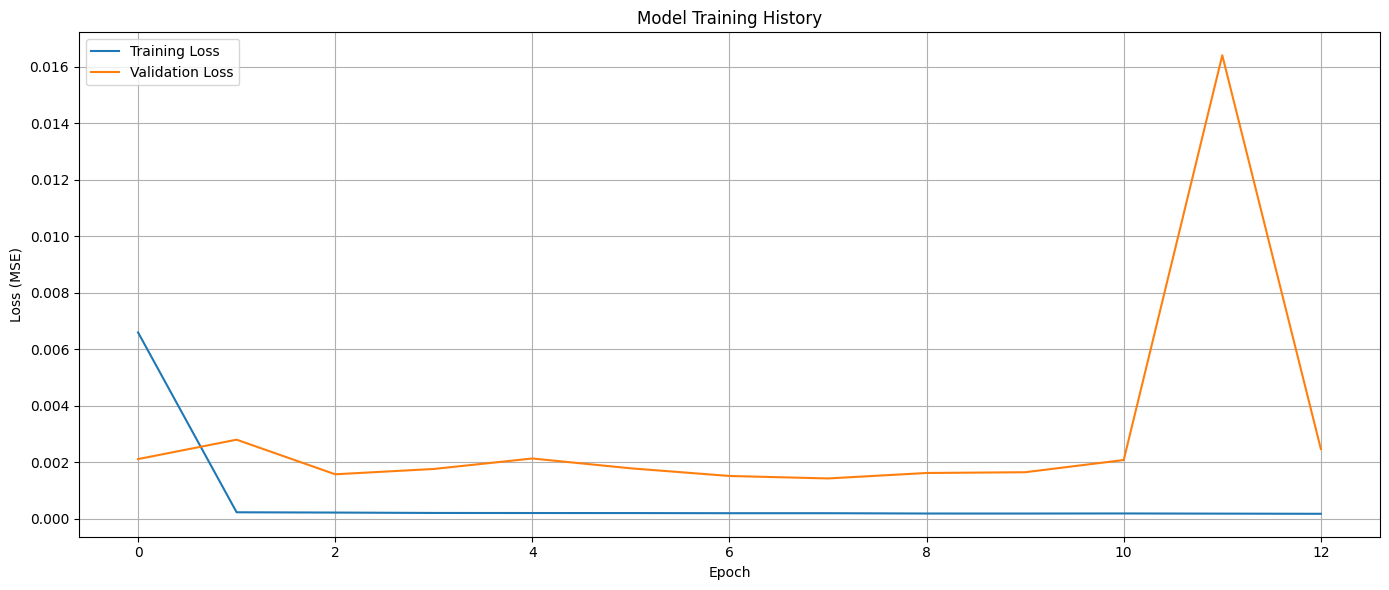

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0017
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


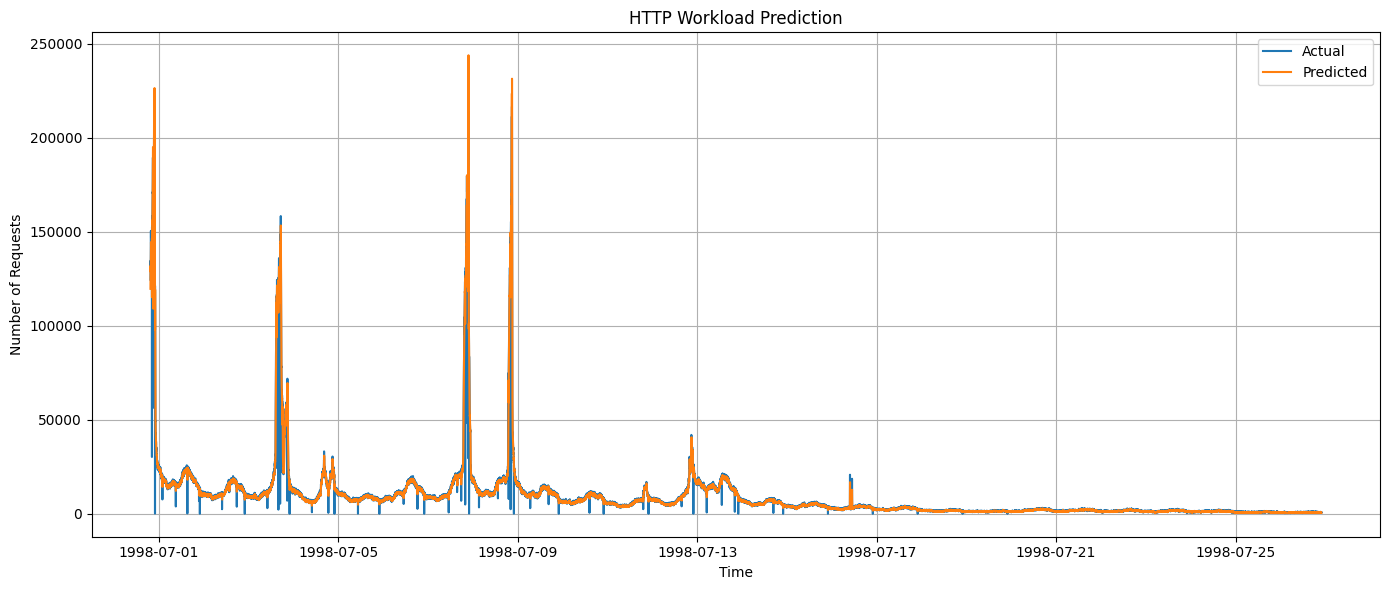

In [8]:
bilstm_dq = BilstmTrainer(hidden_units=30, num_layers=2, input_shape=(10, 1))

bilstm_dq.fit_model(train_data=train_data, epochs=50, batch_size=64, patience=5)
bilstm_dq.plot_history()

test_loss_dq = bilstm_dq.evaluate_model(test_data)

bilstm_dq.set_scaler(scaler)
bilstm_dq.plot_prediction(test_df=test_df, time_step=10)

### hyperparameter config 2 from  Mondal et al., (2023)

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.1413 - val_loss: 0.0026
Epoch 2/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.4908e-04 - val_loss: 0.0025
Epoch 3/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0301e-04 - val_loss: 0.0026
Epoch 4/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1031e-04 - val_loss: 0.0023
Epoch 5/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0277e-04 - val_loss: 0.0019
Epoch 6/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9192e-04 - val_loss: 0.0019
Epoch 7/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9925e-04 - val_loss: 0.0023
Epoch 8/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9764e-04 - val_loss: 0.0015
Epoch 9/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8391e-04 - val_loss: 0.0020
Epoch 10/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9016e-04 - val_loss: 0.0017
Epoch 11/200
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0396e-04 - val_loss: 0.0016
Epoch 12/200

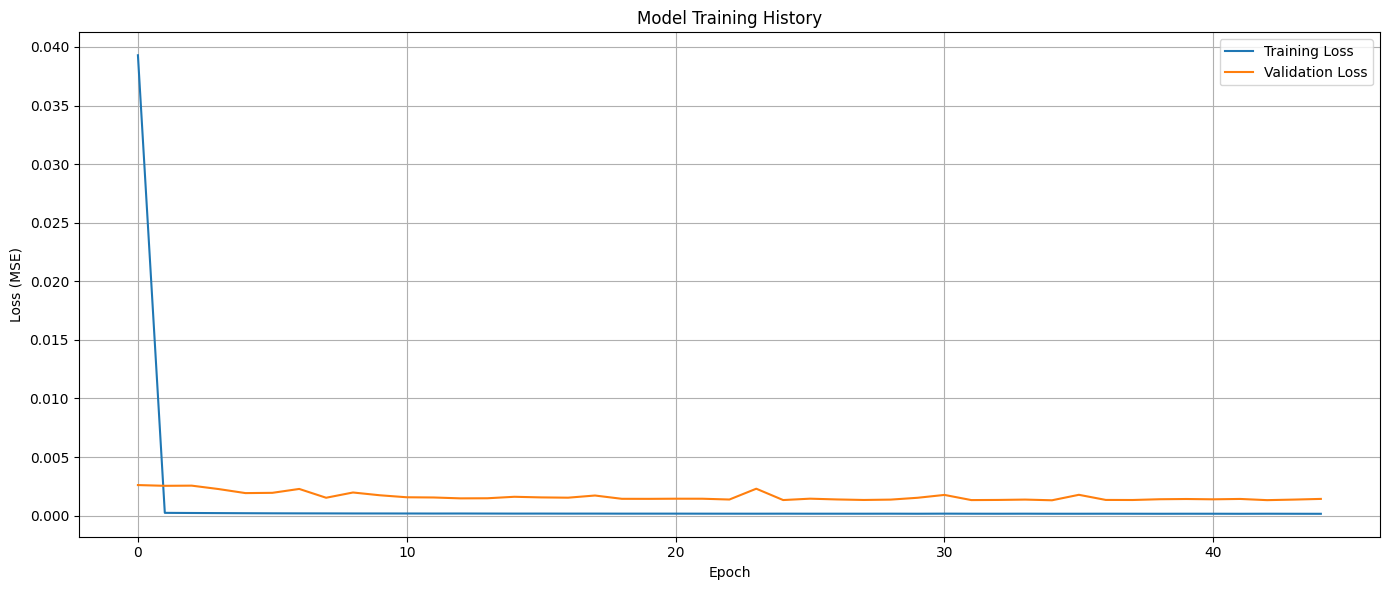

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0015
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


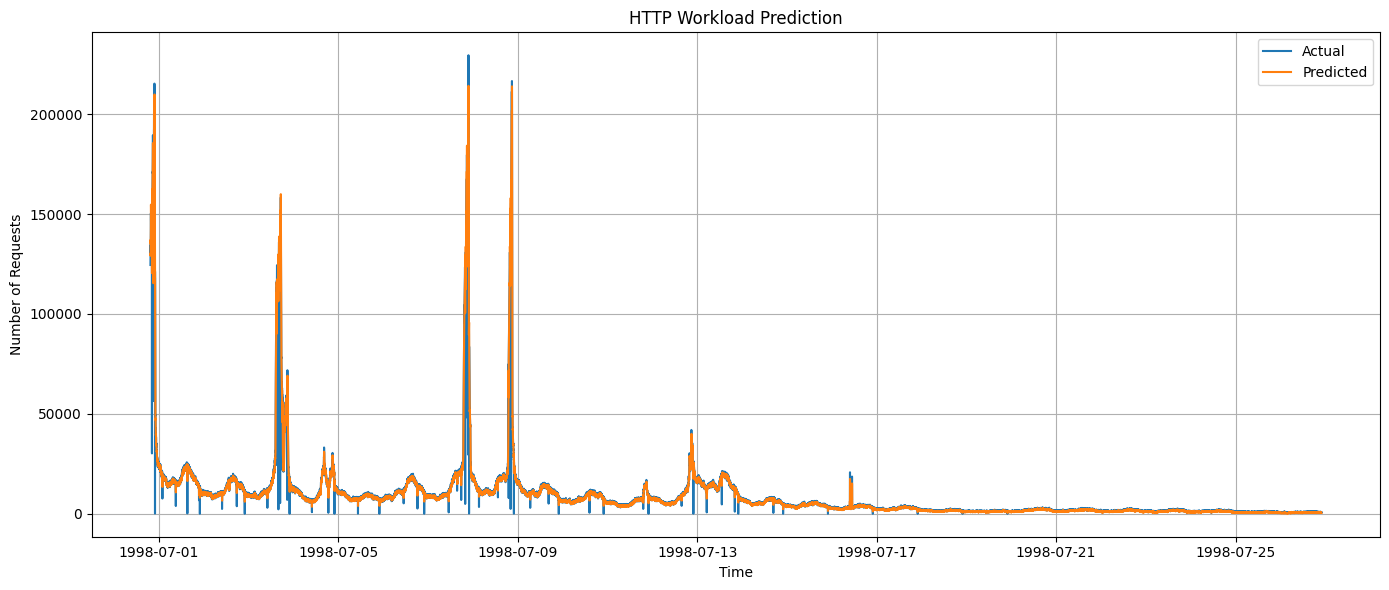

In [9]:
bilstm_md = BilstmTrainer(hidden_units=100, num_layers=1, input_shape=(10, 1))

bilstm_md.fit_model(train_data=train_data, epochs=200, batch_size=512, patience=10)
bilstm_md.plot_history()

test_loss_md = bilstm_md.evaluate_model(test_data)

bilstm_md.set_scaler(scaler)
bilstm_md.plot_prediction(test_df=test_df, time_step=10)

### hyperparametes optmization

In [10]:
best_params = hyperparameter_tuning(
        train_data=train_data,
        test_data=test_data,
        n_trials=100
    )

[I 2026-01-31 23:54:03,377] A new study created in memory with name: bilstm hyperparameters optimization


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0016
[I 2026-01-31 23:54:45,484] Trial 0 finished with value: 0.0005814179894514382 and parameters: {'hidden_units': 47, 'num_layers': 1, 'batch_size': 64, 'epochs': 50, 'patience': 5}. Best is trial 0 with value: 0.0005814179894514382.
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0019
[I 2026-01-31 23:56:08,121] Trial 1 finished with value: 0.0006836209213361144 and parameters: {'hidden_units': 38, 'num_layers': 2, 'batch_size': 128, 'epochs': 50, 'patience': 10}. Best is trial 0 with value: 0.0005814179894514382.
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0015
[I 2026-01-31 23:57:54,619] Trial 2 finished with value: 0.0005234499112702906 and parameters: {'hidden_units': 38, 'num_layers': 2, 'batch_size': 128, 'epochs': 100, 'patience': 10}. Best is trial 2 with value: 0.0005234499112702906.
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0017
[I 2026-01-31 23:59:01,189] Trial 3 finished with value: 0.00059700

### model with best hyperparameters config

In [11]:
print(best_params)

{'hidden_units': 100, 'num_layers': 1, 'batch_size': 64, 'epochs': 150, 'patience': 10}


Epoch 1/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0429 - val_loss: 0.0022
Epoch 2/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.2032e-04 - val_loss: 0.0026
Epoch 3/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.0488e-04 - val_loss: 0.0020
Epoch 4/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.8390e-04 - val_loss: 0.0015
Epoch 5/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.2490e-04 - val_loss: 0.0014
Epoch 6/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.1277e-04 - val_loss: 0.0014
Epoch 7/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.6198e-04 - val_loss: 0.0015
Epoch 8/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.3574e-04 - val_loss: 0.0017
Epoch 9/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.7880e-04 - val_loss: 0.0015
Epoch 10/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.5561e-04 - val_loss: 0.0013
Epoch 11/150
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.3098e-

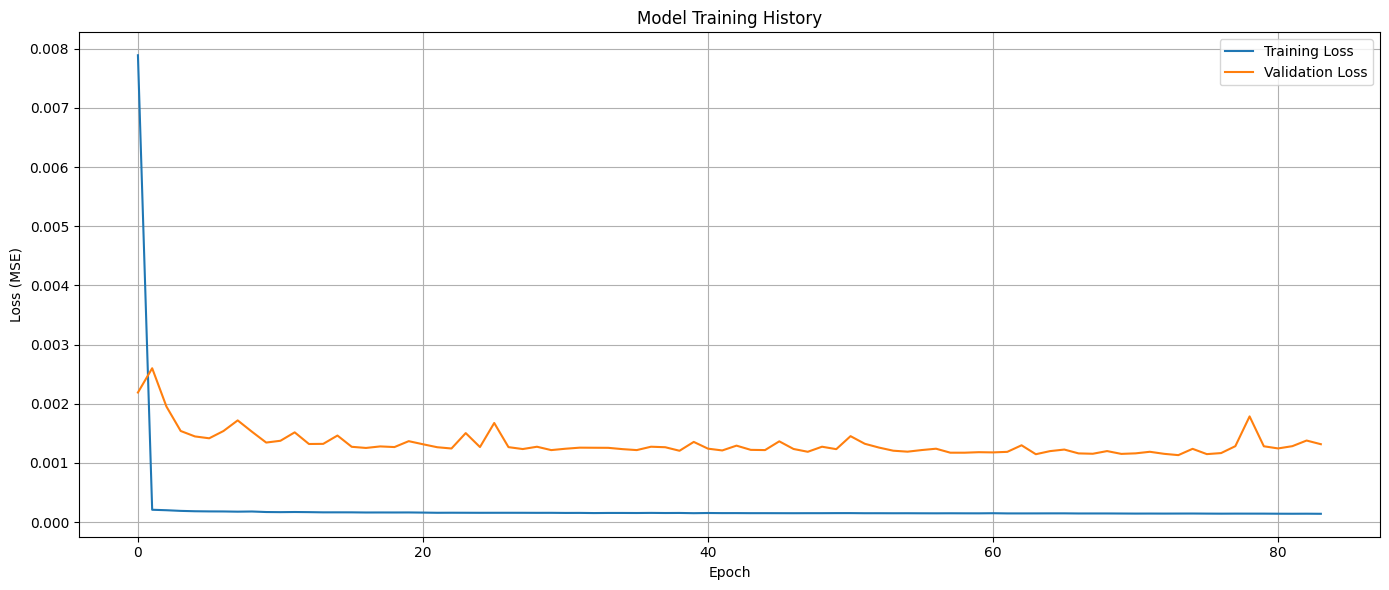

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0012
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


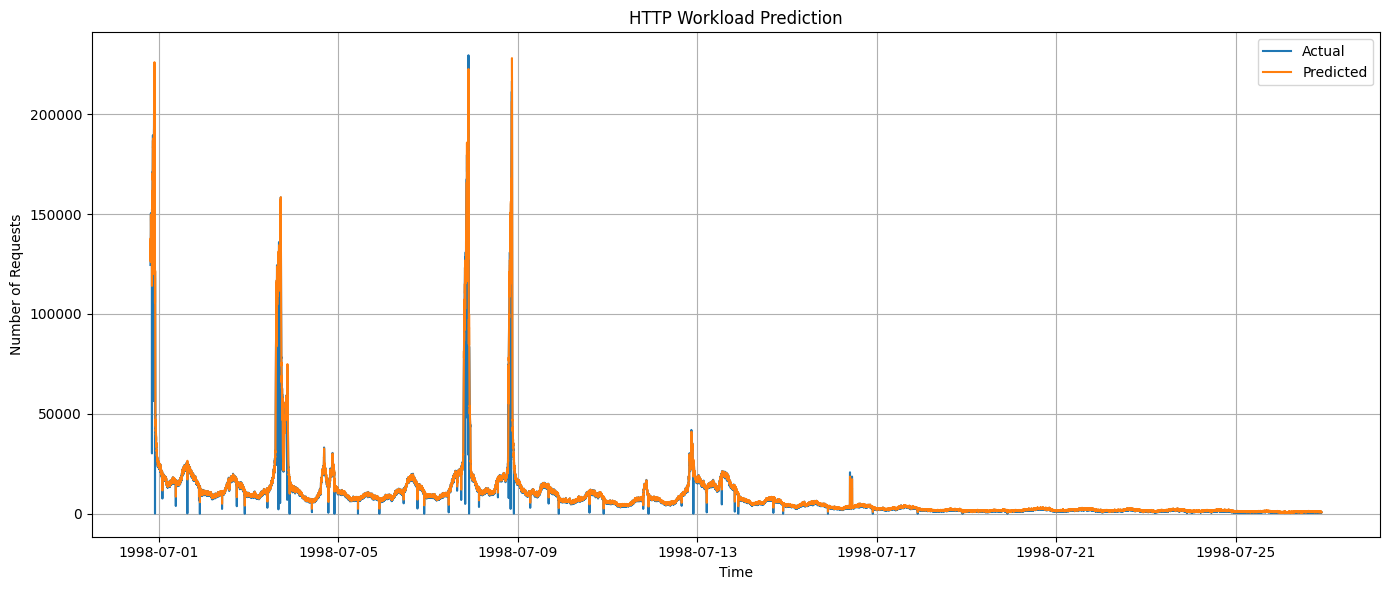

In [12]:
bilstm_opt = BilstmTrainer(
        hidden_units=best_params['hidden_units'], 
        num_layers=best_params['num_layers'], 
        input_shape=(10, 1)
    )
bilstm_opt.fit_model(
        train_data=train_data, 
        epochs=best_params['epochs'], 
        batch_size=best_params['batch_size'],
        patience=best_params['patience']
    )
bilstm_opt.plot_history()

test_loss_opt = bilstm_opt.evaluate_model(test_data)

bilstm_opt.set_scaler(scaler)
bilstm_opt.plot_prediction(test_df=test_df, time_step=10)

# model evaluation

### metrics comparison

In [13]:
metrics_dq = bilstm_dq.calculate_metrics()
metric_speed_dq = bilstm_dq.calculate_prediction_speed()

metrics_md = bilstm_md.calculate_metrics()
metric_speed_md = bilstm_md.calculate_prediction_speed()

metrics_opt = bilstm_opt.calculate_metrics()
metric_speed_opt = bilstm_opt.calculate_prediction_speed()

print("hyperparameter 1")
print(f"test loss : {test_loss_dq:.6f}")
print("hyperparameter 2")
print(f"test loss : {test_loss_md:.6f}")
print("hyperparameter optimized")
print(f"test loss : {test_loss_opt:.6f}")

hyperparameter 1
test loss : 0.000591
hyperparameter 2
test loss : 0.000530
hyperparameter optimized
test loss : 0.000460


In [14]:
print("real value")
print("\n")
print("hyperparameter 1")
for metric, value in metrics_dq.items():
    print(f"- {metric}: {value:.6f}")

print("===")

print("hyperparameter 2")
for metric, value in metrics_md.items():
    print(f"- {metric}: {value:.6f}")

print("===")
    
print("hyperparameter optimized")
for metric, value in metrics_opt.items():
    print(f"- {metric}: {value:.6f}")

real value


hyperparameter 1
- mean_squared_error: 7490737.804362
- root_mean_squared_error: 2736.921227
- mean_absolute_error: 504.896240
- r_squared: 0.978505
===
hyperparameter 2
- mean_squared_error: 6716842.678140
- root_mean_squared_error: 2591.687226
- mean_absolute_error: 520.068750
- r_squared: 0.980726
===
hyperparameter optimized
- mean_squared_error: 5824036.123578
- root_mean_squared_error: 2413.303985
- mean_absolute_error: 514.707073
- r_squared: 0.983288


In [15]:
print("prediction speed")
print("\n")
print("hyperparameter 1")
for metric, value in metric_speed_dq.items():
    print(f"- {metric}: {value:.2f}")

print("===")

print("hyperparameter 2")
for metric, value in metric_speed_md.items():
    print(f"- {metric}: {value:.2f}")

print("===")
    
print("hyperparameter optimized")
for metric, value in metric_speed_opt.items():
    print(f"- {metric}: {value:.2f}")

prediction speed


hyperparameter 1
- avg_batch_time_seconds: 2.55
- avg_single_prediction_ms: 60.57
- std_batch_time_seconds: 0.18
- std_single_prediction_ms: 1.07
===
hyperparameter 2
- avg_batch_time_seconds: 1.63
- avg_single_prediction_ms: 61.70
- std_batch_time_seconds: 0.01
- std_single_prediction_ms: 1.71
===
hyperparameter optimized
- avg_batch_time_seconds: 1.62
- avg_single_prediction_ms: 60.15
- std_batch_time_seconds: 0.01
- std_single_prediction_ms: 0.97


### model improvement after optimization

In [16]:
print(f"Improvement from config #1: {(test_loss_dq - test_loss_opt) / test_loss_dq * 100:.2f}%")

print(f"Improvement from config #2: {(test_loss_md  - test_loss_opt) / test_loss_md  * 100:.2f}%")

Improvement from config #1: 22.25%
Improvement from config #2: 13.29%


# saving model

In [17]:
bilstm_dq.save_model("bilstm_dq", "/kaggle/working")

bilstm_md.save_model("bilstm_md", "/kaggle/working")

bilstm_opt.save_model("bilstm_bo_opt", "/kaggle/working")

bilstm_dq saved successfully
bilstm_md saved successfully
bilstm_bo_opt saved successfully
